# Data exploration

This notebook documents the **four** tabular datasets under `Data/`. Each pair (`*_train.csv` / `*_test.csv`) is a separate modeling problem with its own features and target.

| File stem | Rows (train) | Focus |
|-----------|--------------|--------|
| `medical_risk` | 2,000 | Health risk from vitals and lifestyle |
| `hotel_demand` | 2,000 | Booking / demand prediction |
| `complaint_nlp` | 2,000 | Customer complaint text classification |
| `candidate_success` | 2,000 | Hiring / success prediction from profile signals |

**Outline:** §1–§4 describe each dataset → **Predictors** → **Insights (summary)** → **Data quality issues** (missing values, duplicates, outliers) → structural report (code) → EDA plots → optional automation cells.

The sections below answer, **for each dataset**: (1) description, (2) an E/R-style model, (3) the target variable, and (4) the business problem it represents. The **Predictors** section lists the **main feature variables used for prediction** (everything except `id` and the target label) for each task, right before the insights summary.

**Insights:** After the four dataset write-ups and **Predictors**, section **“Insights (summary)”** pulls together cross-cutting and per-task takeaways and **reminds** you which **task-specific `.ipynb`** files belong to each problem.

**Automation (optional):** At the **end** of this notebook, you can run `scripts/generate_notebooks.py` (rebuilds the four task notebooks under `notebooks/` from `scripts/notebook_sources/`) and `scripts/ml_baseline_pipeline.py` (baseline models + `output/*_predictions.csv`). Keep this file as the single place for narrative insights; scripts are invoked from code cells there.


## 1. Medical risk (`medical_risk_train.csv` / `medical_risk_test.csv`)

### Describe the dataset

Each row is one **patient record** identified by `id`. The features are clinical and behavioral: `age`, `bmi`, `blood_pressure`, `cholesterol_level`, `glucose_level`, plus indicators `smoker`, `physical_activity`, `family_history`, and `stress_level` (numeric scale). The training split has **2,000** rows; labels are imbalanced toward the negative class (**1,329** vs **671** positives for `risk_label`).

### E/R model

Conceptually, one entity **PatientRecord** holds measurements and the outcome used for supervised learning. The diagram treats `risk_label` as the prediction target linked to the same record.

```mermaid
erDiagram
    PATIENT_RECORD {
        int id PK
        int age
        float bmi
        int blood_pressure
        int cholesterol_level
        int glucose_level
        int smoker
        int physical_activity
        int family_history
        int stress_level
        int risk_label "target"
    }
```

### What is the target variable?

- **`risk_label`** — binary outcome: **1** = higher modeled health risk, **0** = lower risk (e.g., for prioritization or screening).

### Business problem

A healthcare analytics or insurer use case: **prioritize patients for follow-up, prevention programs, or resource allocation** by predicting elevated risk from routine measurements and questionnaire-style inputs, without replacing clinical diagnosis.


## 2. Hotel demand (`hotel_demand_train.csv` / `hotel_demand_test.csv`)

### Describe the dataset

Each row is one **booking** (or booking request) with operational attributes: `hotel_type`, `lead_time_days`, `stay_length`, `num_adults`, `num_children`, `season`, `price_per_night`, `previous_bookings`, `special_requests`. Training has **2,000** rows; `demand_label` is roughly **1,143** vs **857** between the two classes.

### E/R model

Single entity **Booking** with all reservation-side attributes and the demand outcome.

```mermaid
erDiagram
    BOOKING {
        int id PK
        int hotel_type
        int lead_time_days
        int stay_length
        int num_adults
        int num_children
        int season
        float price_per_night
        int previous_bookings
        int special_requests
        int demand_label "target"
    }
```

### What is the target variable?

- **`demand_label`** — binary label for **demand level** associated with the booking context (e.g., high vs low demand period or intensity; align with your course definition if provided).

### Business problem

**Revenue and operations planning**: forecast whether a booking pattern corresponds to high demand so the hotel can adjust **pricing, staffing, and inventory** (rooms, amenities) ahead of peak or slack periods.


## 3. Customer complaints — NLP (`complaint_nlp_train.csv` / `complaint_nlp_test.csv`)

### Describe the dataset

Each row is one **customer complaint** with free text `complaint_text` and a single categorical **`category_label`**. Training has **2,000** rows; categories are roughly balanced (**about 368–418** rows per class across five categories: `booking`, `billing`, `cleanliness`, `service`, `technical`).

### E/R model

One entity **Complaint** stores the message; the category is the supervised label. In a normalized database, categories would live in a lookup table referenced by foreign key.

```mermaid
erDiagram
    COMPLAINT {
        int id PK
        string complaint_text
        string category_label "target"
    }
    COMPLAINT_CATEGORY {
        string name PK
    }
    COMPLAINT }o--|| COMPLAINT_CATEGORY : references
```

*(In the flat CSV, `category_label` is denormalized text on each row.)*

### What is the target variable?

- **`category_label`** — **multi-class** outcome: which theme or routing bucket the complaint belongs to (`booking`, `billing`, `cleanliness`, `service`, `technical`).

### Business problem

**Automated routing and analytics**: classify inbound complaints so they reach the **right team** quickly, track issue mix over time, and reduce manual triage in support or hospitality operations.


## 4. Candidate success (`candidate_success_train.csv` / `candidate_success_test.csv`)

### Describe the dataset

Each row is one **candidate** (applicant) profile: `experience_years`, `python_skill_score`, `ml_skill_score`, `projects_completed`, `education_level`, `github_activity`, `communication_score`, `certifications`. Training has **2,000** rows; `success_label` is **1,210** vs **790** for the two classes.

### E/R model

Single entity **Candidate** aggregating résumé-like signals and the hiring outcome.

```mermaid
erDiagram
    CANDIDATE {
        int id PK
        int experience_years
        int python_skill_score
        int ml_skill_score
        int projects_completed
        int education_level
        int github_activity
        int communication_score
        int certifications
        int success_label "target"
    }
```

### What is the target variable?

- **`success_label`** — binary outcome indicating **whether the candidate is successful** under the problem definition (e.g., offer extended, passed a hiring bar, or met a success criterion).

### Business problem

**Recruiting and talent analytics**: predict **hire or success potential** from structured skill and activity features to support **screening, interview prioritization, and workforce planning** (with appropriate fairness and governance in real deployments).


## Predictors — main feature variables for prediction

**Question:** *List the main feature variables used for prediction.*

Those variables are the **predictors**: every column in the training CSV **except** `id` and the **target** (label). Held-out test files include the same predictors (and `id`) but omit the label so you can output predictions.

| Dataset (`*_train.csv`) | Target (label) | Predictors (main feature variables) |
|-------------------------|----------------|--------------------------------------|
| `medical_risk` | `risk_label` | `age`, `bmi`, `blood_pressure`, `cholesterol_level`, `glucose_level`, `smoker`, `physical_activity`, `family_history`, `stress_level` |
| `hotel_demand` | `demand_label` | `hotel_type`, `lead_time_days`, `stay_length`, `num_adults`, `num_children`, `season`, `price_per_night`, `previous_bookings`, `special_requests` |
| `complaint_nlp` | `category_label` | `complaint_text` |
| `candidate_success` | `success_label` | `experience_years`, `python_skill_score`, `ml_skill_score`, `projects_completed`, `education_level`, `github_activity`, `communication_score`, `certifications` |

**Counts:** three tabular tasks each have **nine** numeric or integer predictors; the NLP task has **one** text predictor. Task-specific notebooks may add engineered features on top of these raw inputs.


## Insights (summary)

This notebook is the **single place** for cross-dataset narrative, structural checks, and EDA figures. The bullets below collect the main **takeaways** from sections **1–4** and from the **quality report** and **visualizations** later in this file.

### Five takeaways (read with the charts)

The **quality report** (shapes, duplicates, missing values) and the **EDA plots** further down tell a compact story. Together they support the following five points—each one is easier to interpret with the corresponding figures on screen:

1. **Complaint NLP is dominated by repetition.** The structural report shows thousands of duplicate rows for the same text and category, and the complaint plots reveal very few unique messages and uneven text length by category—so NLP models can look artificially strong unless you account for leakage and overfitting.
2. **Medical risk tracks age and continuous vitals.** Correlation and distribution plots show **age**, **cholesterol**, and **blood pressure** standing out versus `risk_label`, with smokers and family history lifting average risk—consistent with a vitals-heavy, moderately imbalanced classification task.
3. **Hotel demand is driven by season and booking timing.** Bar and boxplot views show **season** splitting demand rates clearly, while **lead time** and **nightly price** differ between high- and low-demand rows—operations and pricing features matter more than hotel type alone in this sample.
4. **Candidate success aligns with skills and delivery, not credentials alone.** The candidate correlation view highlights **projects completed** and **ML skill score**; **education level** looks comparatively flat against success—useful when choosing which signals to emphasize in a hiring model.
5. **Three tabular datasets are “clean” in the narrow sense.** For medical, hotel, and candidate data, the checks report **no missing values** and **no duplicate feature–target rows** (aside from `id`), so any modeling issues are more about signal and imbalance than messy tables.

### Cross-cutting

- **Four supervised tasks** in `Data/`, each with **2,000** training rows and **500** test rows (NLP test has only `id` + `complaint_text`).
- **Tabular tasks** (`medical_risk`, `hotel_demand`, `candidate_success`): In the checks below, **no missing values**; **no duplicate** full rows or duplicate feature+target rows (ignoring `id`).
- **`complaint_nlp`**: **Many duplicate rows** when comparing the same `complaint_text` + `category_label` (ignoring `id`)—the same message can appear multiple times; interpret metrics and leakage accordingly.

### Per task

| Task | Target | Insight (from this notebook) |
|------|--------|-------------------------------|
| `medical_risk` | `risk_label` (binary) | **Imbalanced** (~two-thirds negative); figures show **age** and **smoker** associated with `risk_label`. |
| `hotel_demand` | `demand_label` (binary) | **Season**, **hotel_type**, **price_per_night**, and **lead_time_days** relate to demand in the charts below. |
| `complaint_nlp` | `category_label` (5-way) | Categories are **roughly balanced**; **text length** differs by category; duplicates dominate row counts. |
| `candidate_success` | `success_label` (binary) | **Skill and activity** features show clearer correlation with success than **education_level** in the correlation plot. |

### Task-specific notebooks (created alongside this repo)

For **per-dataset** notebooks (profiling, modeling narrative, exports), open the matching file under **`notebooks/`**. They are **assembled from** `scripts/notebook_sources/*.nb.txt` when you run `python scripts/generate_notebooks.py`:

| Notebook | Dataset |
|----------|---------|
| `notebooks/medical_risk.ipynb` | Medical risk |
| `notebooks/hotel_demand.ipynb` | Hotel demand |
| `notebooks/complaint_nlp.ipynb` | Customer complaints (NLP) |
| `notebooks/candidate_success.ipynb` | Candidate success |

**Reminder:** After editing any `scripts/notebook_sources/<name>.nb.txt`, run `python scripts/generate_notebooks.py` to refresh the corresponding `.ipynb`. Optional: `scripts/ml_baseline_pipeline.py` writes `output/*_predictions.csv` and plots under `figures/` (see the automation cells at the **end** of this notebook).

## Data quality issues

This section **identifies** data-quality concerns—**missing values**, **duplicates**, and **outliers**—at a glance. The **code cell** under *Structural checks and data quality* (next) prints the full, reproducible report for every train/test split.

### Summary

| Dataset | Missing values | Duplicates (same predictors + target, ignoring `id`) | Outliers |
|---------|----------------|------------------------------------------------------|----------|
| `medical_risk` | None in train or test | **None** | Numeric features: IQR rule (values outside \(Q1 - 1.5 \cdot IQR\) or \(Q3 + 1.5 \cdot IQR\)). |
| `hotel_demand` | None | **None** | Same IQR rule on numeric columns. |
| `complaint_nlp` | None | **Severe** on train (**1,975** rows; only **~25** unique complaint texts) and high on test (**475** duplicate feature+label rows)—the main quality risk for NLP. | IQR rule applied to **complaint text length** (characters). |
| `candidate_success` | None | **None** | IQR rule on numeric features. |

### How to read these issues

1. **Missing values:** In this repo’s CSVs, structural checks report **no** missing entries—there is nothing to drop or impute for nulls in the raw files.
2. **Duplicates:** **Tabular** tasks have **no** duplicate rows when comparing all columns except `id` (same inputs and same label). **`complaint_nlp`** breaks that pattern: the same text+category appears many times with different `id` values, which affects train/validation design and can inflate model scores.
3. **Outliers:** Flags are **univariate** and **rule-based** (IQR). Discrete or bounded fields often produce **zero** or few flags; that does not prove “no unusual records” in a business sense—only that values are not extreme relative to their column’s quartiles.

*Re-run the structural report cell below after refreshing `Data/` if files change.*


## Structural checks and data quality

The **Data quality issues** section above summarizes findings; **this** subsection defines what the automated report measures. For **each CSV pair** in `Data/`, the code cell below prints:

- **Shape** — number of rows and columns (train and test).
- **Predictors** — columns used as inputs (excluding `id` and the target); see also the **Predictors** section above for the full list per dataset.
- **Data quality** — missing values; duplicate rows (full row and excluding `id`); univariate **numeric outliers** via the IQR rule (values outside \(Q1 - 1.5 \cdot IQR\) or \(Q3 + 1.5 \cdot IQR\)); for `complaint_text`, the same rule applied to **string length** flags unusually short or long messages.

*Note: Many fields are discrete or bounded, so IQR may flag few or no numeric outliers even when values look "extreme" in a business sense.*


In [3]:
from pathlib import Path

import pandas as pd
from IPython.display import display

def _project_root() -> Path:
    p = Path.cwd().resolve()
    if (p / "Data").is_dir():
        return p
    if p.name == "notebooks" and (p.parent / "Data").is_dir():
        return p.parent
    return p


DATA_DIR = _project_root() / "Data"

TASKS = [
    ("medical_risk", "risk_label"),
    ("hotel_demand", "demand_label"),
    ("complaint_nlp", "category_label"),
    ("candidate_success", "success_label"),
]


def iqr_outlier_mask(s: pd.Series) -> pd.Series:
    """True where numeric value is outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR]."""
    x = pd.to_numeric(s, errors="coerce")
    if x.notna().sum() == 0:
        return pd.Series(False, index=s.index)
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return pd.Series(False, index=s.index)
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (x < lo) | (x > hi)


def report_split(name: str, df: pd.DataFrame, target: str) -> None:
    feat_cols = [c for c in df.columns if c not in ("id", target)]
    print(f"  Rows: {len(df):,}  |  Columns: {df.shape[1]}")
    print(f"  Features for prediction ({len(feat_cols)}): {feat_cols}")

    miss = df.isna().sum()
    if miss.sum() == 0:
        print("  Missing values: none")
    else:
        print(f"  Missing values (total): {int(miss.sum())}")
        print(miss[miss > 0].to_string())

    dup_all = int(df.duplicated().sum())
    cols_no_id = [c for c in df.columns if c != "id"]
    dup_no_id = int(df.duplicated(subset=cols_no_id).sum())
    print(f"  Duplicate rows (all columns): {dup_all}")
    print(f"  Duplicate rows (same feature+target, ignoring id): {dup_no_id}")

    num_feats = [c for c in feat_cols if pd.api.types.is_numeric_dtype(df[c])]
    any_out_idx = set()
    for col in num_feats:
        m = iqr_outlier_mask(df[col])
        if m.any():
            print(f"  IQR outliers in feature {col!r}: {int(m.sum())} cell(s)")
            any_out_idx.update(df.index[m])
    if num_feats and any_out_idx:
        print(f"  Rows with >=1 numeric feature outlier (any column): {len(any_out_idx)}")

    if "complaint_text" in df.columns:
        lens = df["complaint_text"].astype(str).str.len()
        q1, q3 = lens.quantile(0.25), lens.quantile(0.75)
        iqr = q3 - q1
        if iqr > 0:
            lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            mlen = (lens < lo) | (lens > hi)
            if mlen.any():
                print(
                    f"  IQR outliers on complaint_text length: {int(mlen.sum())} row(s)"
                )


for stem, target in TASKS:
    print("=" * 72)
    print(stem)
    print("-" * 72)
    train = pd.read_csv(DATA_DIR / f"{stem}_train.csv")
    test = pd.read_csv(DATA_DIR / f"{stem}_test.csv")
    print("TRAIN")
    report_split(stem, train, target)
    print("TEST")
    report_split(stem, test, target)

summary_rows = []
for stem, target in TASKS:
    tr = pd.read_csv(DATA_DIR / f"{stem}_train.csv")
    te = pd.read_csv(DATA_DIR / f"{stem}_test.csv")
    summary_rows.append(
        {
            "dataset": stem,
            "split": "train",
            "rows": len(tr),
            "columns": tr.shape[1],
        }
    )
    summary_rows.append(
        {
            "dataset": stem,
            "split": "test",
            "rows": len(te),
            "columns": te.shape[1],
        }
    )

summary_df = pd.DataFrame(summary_rows)
display(summary_df)


medical_risk
------------------------------------------------------------------------
TRAIN
  Rows: 2,000  |  Columns: 11
  Features for prediction (9): ['age', 'bmi', 'blood_pressure', 'cholesterol_level', 'glucose_level', 'smoker', 'physical_activity', 'family_history', 'stress_level']
  Missing values: none
  Duplicate rows (all columns): 0
  Duplicate rows (same feature+target, ignoring id): 0
TEST
  Rows: 500  |  Columns: 10
  Features for prediction (9): ['age', 'bmi', 'blood_pressure', 'cholesterol_level', 'glucose_level', 'smoker', 'physical_activity', 'family_history', 'stress_level']
  Missing values: none
  Duplicate rows (all columns): 0
  Duplicate rows (same feature+target, ignoring id): 0
hotel_demand
------------------------------------------------------------------------
TRAIN
  Rows: 2,000  |  Columns: 11
  Features for prediction (9): ['hotel_type', 'lead_time_days', 'stay_length', 'num_adults', 'num_children', 'season', 'price_per_night', 'previous_bookings', 'speci

,dataset,split,rows,columns
0,medical_risk,train,2000,11
1,medical_risk,test,500,10
2,hotel_demand,train,2000,11
3,hotel_demand,test,500,10
4,complaint_nlp,train,2000,3
5,complaint_nlp,test,500,2
6,candidate_success,train,2000,10
7,candidate_success,test,500,9


## Exploratory data analysis (EDA)

All plots below use **training** CSVs only (`*_train.csv`) so we do not peek at test labels. The goal is to visualize distributions, relationships with targets, and data-quality issues.

### Top 3 insights (priority)

1. **Complaint NLP — duplicate messages:** The training set contains only **25 unique complaint texts** for 2,000 rows, with nearly identical rows repeated many times. **This dominates modeling choices** (e.g. memorization, split leakage, need for deduplication or augmentation).

2. **Medical risk — age and labs:** **Age** shows the strongest linear association with `risk_label`, followed by **cholesterol** and **blood pressure**. Models should expect strong signal from continuous vitals.

3. **Hotel demand — season and lead time:** **Season** separates high vs low demand rates clearly; **higher demand** is associated with **shorter booking lead times** and **lower average nightly price** in this sample—useful features for forecasting and sanity checks.

### 10 insights (summary)

| # | Insight |
|---|--------|
| 1 | Complaint data: **~25 unique texts**, 1,975 duplicate rows (same text + category, different `id`) — high **leakage / overfitting** risk for NLP. |
| 2 | Medical: **Age** has the strongest Pearson correlation with `risk_label`; cholesterol and blood pressure follow. |
| 3 | Medical: **Class imbalance** — ~33% high risk (`risk_label=1`) vs 67% low. |
| 4 | Medical: **Smokers** and **family history** show higher mean risk than non-smokers / no history (marginal rates). |
| 5 | Hotel: **Season** strongly stratifies `demand_label` (e.g. season 4 vs 1). |
| 6 | Hotel: **High demand** rows have **lower mean price** and **much shorter lead time** than low demand. |
| 7 | Hotel: **Hotel type** shows similar demand rates between types — weaker than season. |
| 8 | Complaints: Categories are **roughly balanced**; **service** texts are longest on average, **cleanliness** shortest. |
| 9 | Candidate: **Projects completed** and **ML skill score** have the strongest correlations with `success_label`. |
| 10 | Candidate: **Education level** is near-flat vs success rate in this sample — weak linear predictor. |

*Correlations are Pearson on numeric columns; rates are sample means in the training split.*


C:\Users\lneri\AppData\Local\Temp\ipykernel_19208\1905833416.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=medical, x="risk_label", y="age", ax=axes1[1, 0], palette="Set2")
C:\Users\lneri\AppData\Local\Temp\ipykernel_19208\1905833416.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=hotel, x="demand_label", y="price_per_night", ax=axes2[1, 0], palette="pastel")
C:\Users\lneri\AppData\Local\Temp\ipykernel_19208\1905833416.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=hotel, x="demand_label", y="lead_time_days",

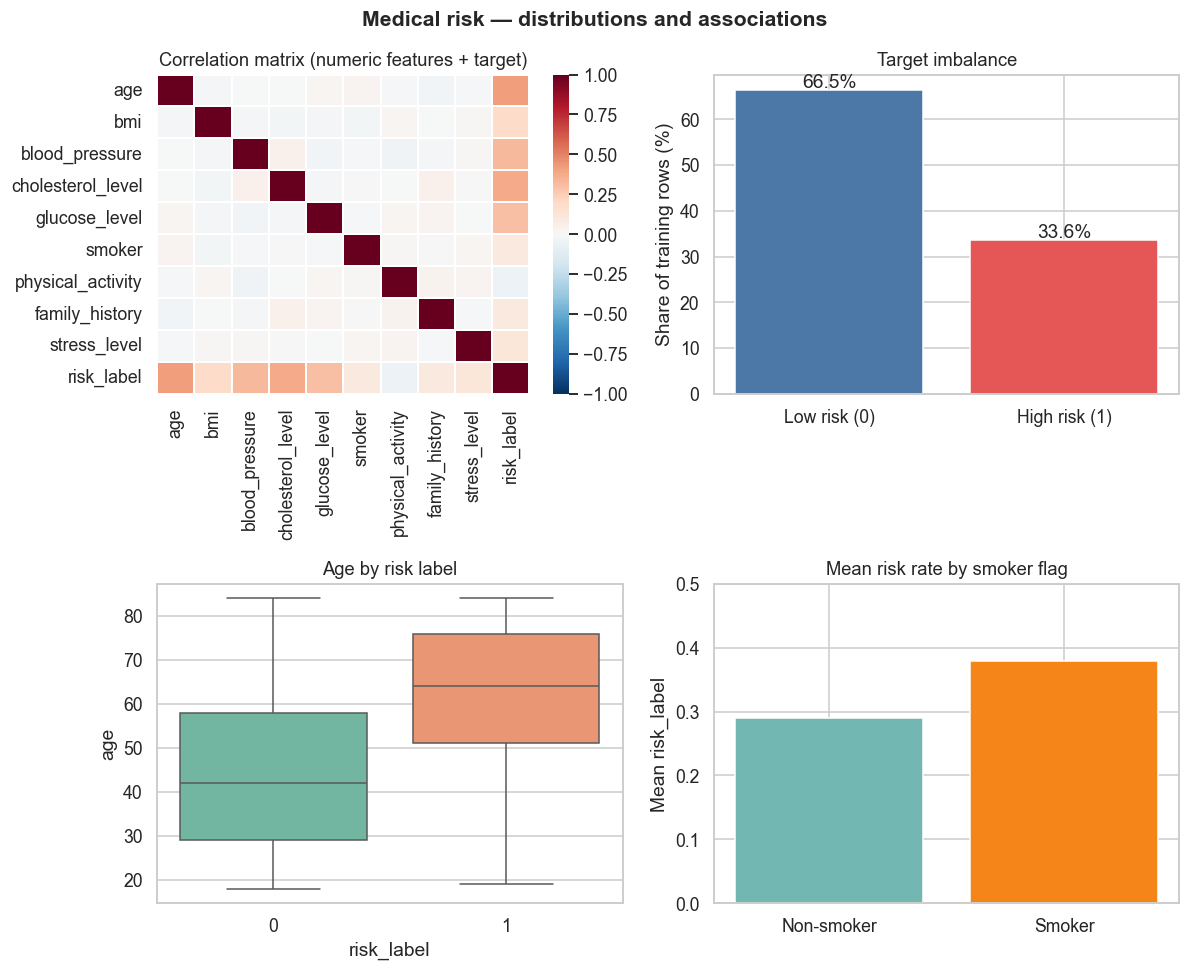

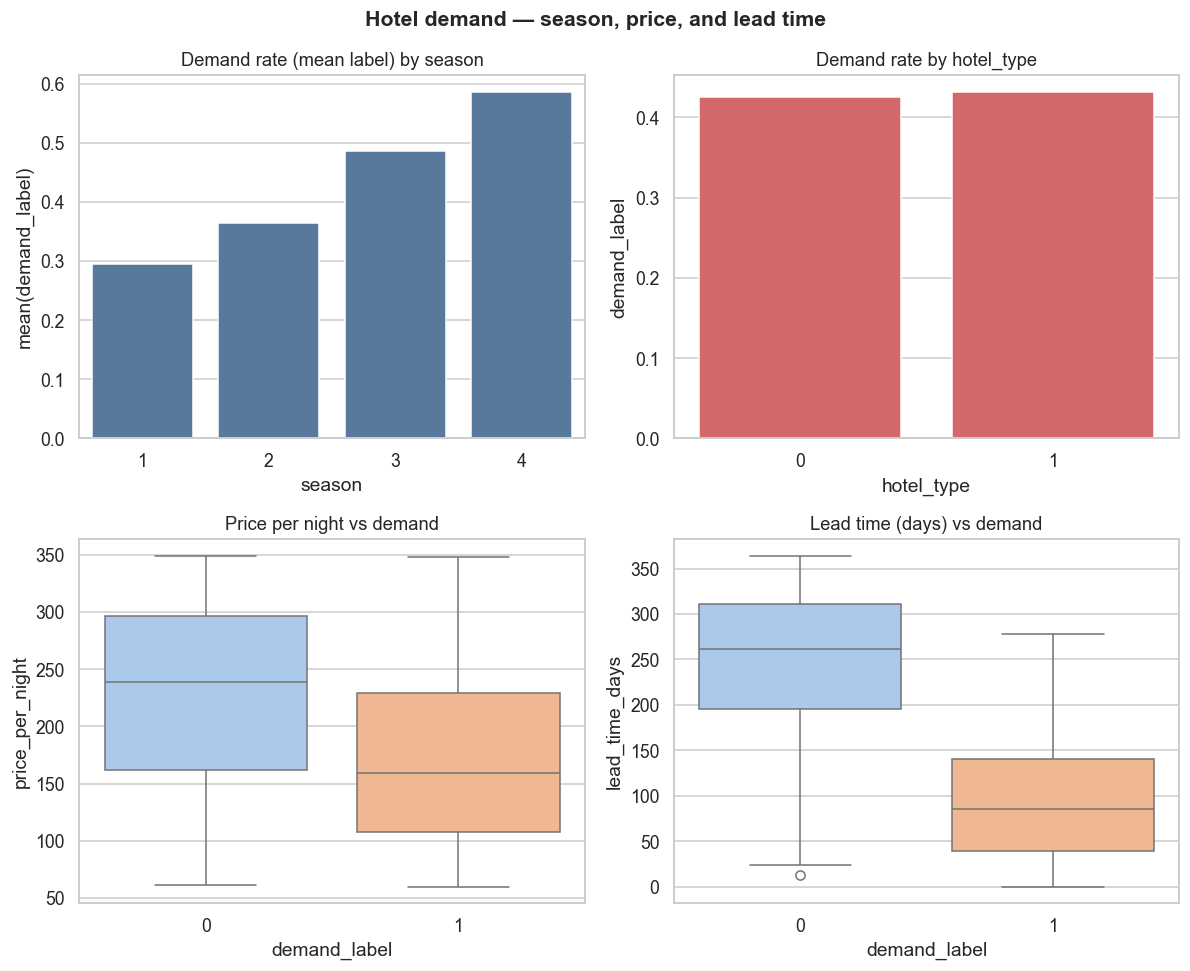

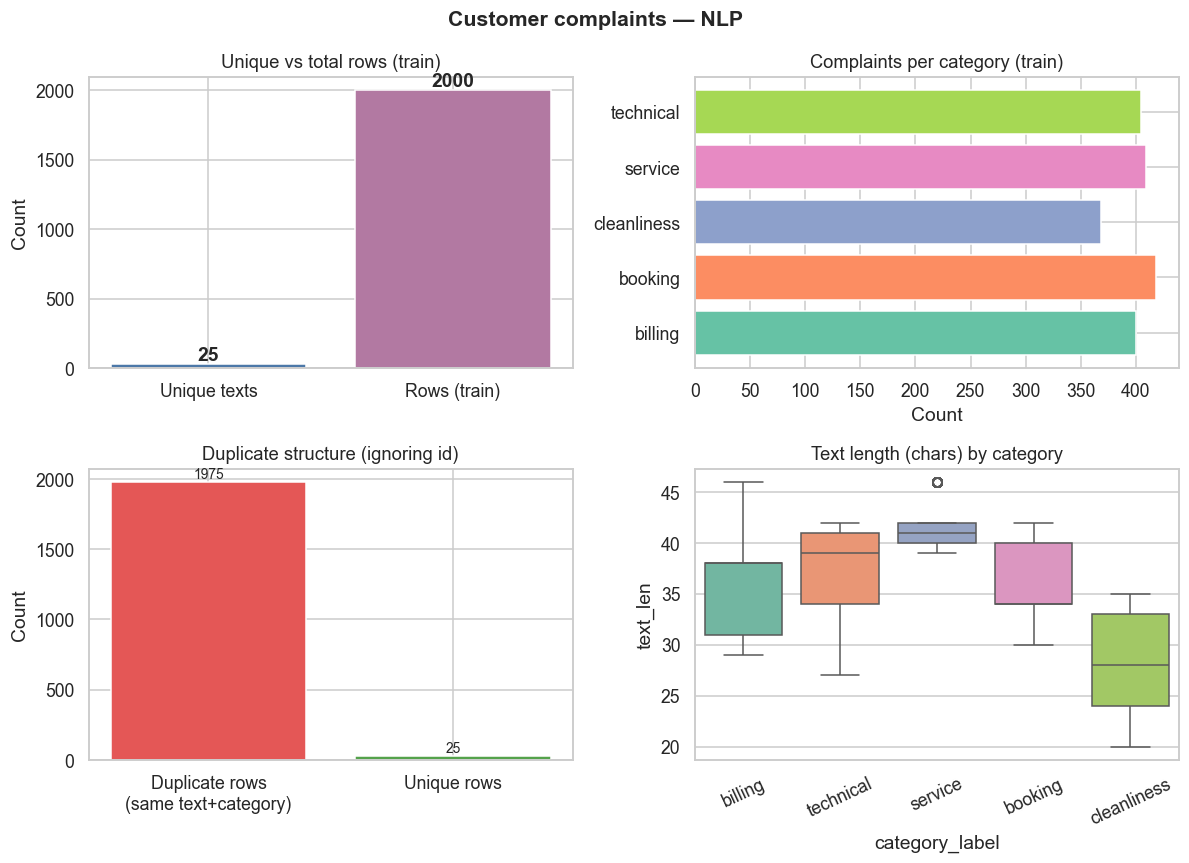

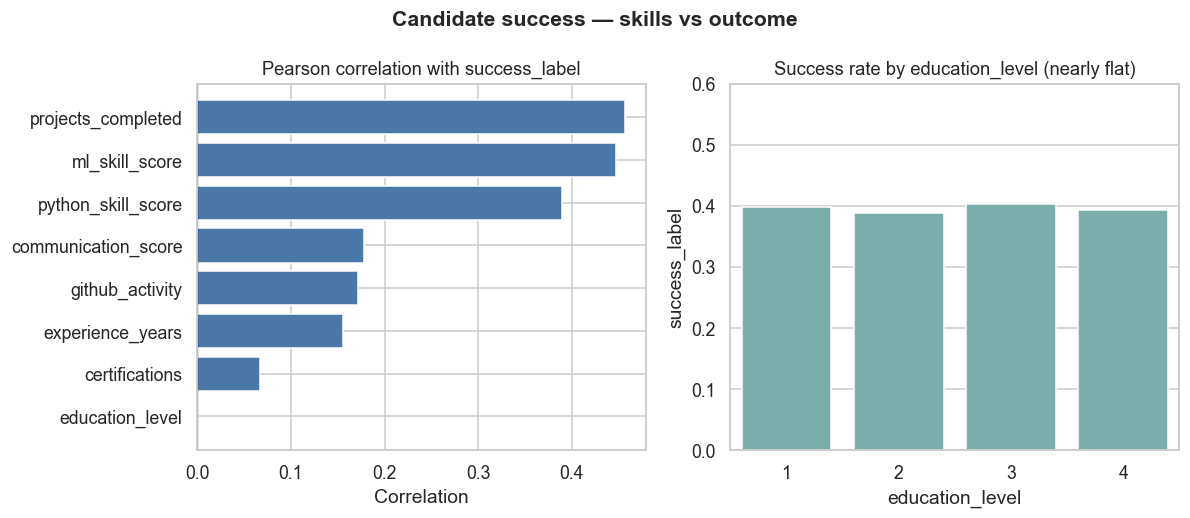

In [3]:
# EDA — set matplotlib backend for notebooks
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def _project_root() -> Path:
    p = Path.cwd().resolve()
    if (p / "Data").is_dir():
        return p
    if p.name == "notebooks" and (p.parent / "Data").is_dir():
        return p.parent
    return p


DATA_DIR = _project_root() / "Data"

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12

medical = pd.read_csv(DATA_DIR / "medical_risk_train.csv")
hotel = pd.read_csv(DATA_DIR / "hotel_demand_train.csv")
complaints = pd.read_csv(DATA_DIR / "complaint_nlp_train.csv")
candidates = pd.read_csv(DATA_DIR / "candidate_success_train.csv")

# --- Figure 1 — Medical risk ---
fig1, axes1 = plt.subplots(2, 2, figsize=(11, 9))
fig1.suptitle("Medical risk — distributions and associations", fontsize=14, fontweight="bold")

feat_num = [c for c in medical.columns if c not in ("id", "risk_label")]
corr = medical[feat_num + ["risk_label"]].corr()
sns.heatmap(
    corr,
    ax=axes1[0, 0],
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    annot=False,
    linewidths=0.3,
)
axes1[0, 0].set_title("Correlation matrix (numeric features + target)")

risk_rate = medical.groupby("risk_label", as_index=False).size()
risk_rate["pct"] = risk_rate["size"] / risk_rate["size"].sum() * 100
axes1[0, 1].bar(["Low risk (0)", "High risk (1)"], risk_rate["pct"], color=["#4C78A8", "#E45756"])
axes1[0, 1].set_ylabel("Share of training rows (%)")
axes1[0, 1].set_title("Target imbalance")
for i, v in enumerate(risk_rate["pct"]):
    axes1[0, 1].text(i, v + 0.5, f"{v:.1f}%", ha="center")

sns.boxplot(data=medical, x="risk_label", y="age", ax=axes1[1, 0], palette="Set2")
axes1[1, 0].set_title("Age by risk label")
axes1[1, 0].set_xlabel("risk_label")

smoker_risk = medical.groupby("smoker")["risk_label"].mean().rename({0: "Non-smoker", 1: "Smoker"})
axes1[1, 1].bar(smoker_risk.index.astype(str), smoker_risk.values, color=["#72B7B2", "#F58518"])
axes1[1, 1].set_ylabel("Mean risk_label")
axes1[1, 1].set_title("Mean risk rate by smoker flag")
axes1[1, 1].set_ylim(0, 0.5)

plt.tight_layout()

# --- Figure 2 — Hotel demand ---
fig2, axes2 = plt.subplots(2, 2, figsize=(11, 9))
fig2.suptitle("Hotel demand — season, price, and lead time", fontsize=14, fontweight="bold")

by_season = hotel.groupby("season")["demand_label"].mean().reset_index()
sns.barplot(data=by_season, x="season", y="demand_label", ax=axes2[0, 0], color="#4C78A8")
axes2[0, 0].set_title("Demand rate (mean label) by season")
axes2[0, 0].set_ylabel("mean(demand_label)")
axes2[0, 0].set_xlabel("season")

by_type = hotel.groupby("hotel_type")["demand_label"].mean().reset_index()
sns.barplot(data=by_type, x="hotel_type", y="demand_label", ax=axes2[0, 1], color="#E45756")
axes2[0, 1].set_title("Demand rate by hotel_type")

sns.boxplot(data=hotel, x="demand_label", y="price_per_night", ax=axes2[1, 0], palette="pastel")
axes2[1, 0].set_title("Price per night vs demand")

sns.boxplot(data=hotel, x="demand_label", y="lead_time_days", ax=axes2[1, 1], palette="pastel")
axes2[1, 1].set_title("Lead time (days) vs demand")

plt.tight_layout()

# --- Figure 3 — Complaints ---
complaints = complaints.copy()
complaints["text_len"] = complaints["complaint_text"].astype(str).str.len()

fig3, axes3 = plt.subplots(2, 2, figsize=(11, 8))
fig3.suptitle("Customer complaints — NLP", fontsize=14, fontweight="bold")

uniques = complaints["complaint_text"].nunique()
n_rows = len(complaints)
axes3[0, 0].bar(
    ["Unique texts", "Rows (train)"],
    [uniques, n_rows],
    color=["#4C78A8", "#B279A2"],
)
axes3[0, 0].set_title("Unique vs total rows (train)")
axes3[0, 0].set_ylabel("Count")
for i, v in enumerate([uniques, n_rows]):
    axes3[0, 0].text(i, v + 30, str(int(v)), ha="center", fontweight="bold")

cat_counts = complaints["category_label"].value_counts().sort_index()
axes3[0, 1].barh(cat_counts.index.astype(str), cat_counts.values, color=sns.color_palette("Set2", len(cat_counts)))
axes3[0, 1].set_title("Complaints per category (train)")
axes3[0, 1].set_xlabel("Count")

dup_n = complaints.duplicated(subset=["complaint_text", "category_label"]).sum()
axes3[1, 0].bar(["Duplicate rows\n(same text+category)", "Unique rows"], [dup_n, n_rows - dup_n], color=["#E45756", "#54A24B"])
axes3[1, 0].set_title("Duplicate structure (ignoring id)")
axes3[1, 0].set_ylabel("Count")
for i, v in enumerate([dup_n, n_rows - dup_n]):
    axes3[1, 0].text(i, v + 30, str(int(v)), ha="center", fontsize=9)

sns.boxplot(data=complaints, x="category_label", y="text_len", ax=axes3[1, 1], palette="Set2")
axes3[1, 1].set_title("Text length (chars) by category")
axes3[1, 1].tick_params(axis="x", rotation=25)

plt.tight_layout()

# --- Figure 4 — Candidate success ---
fig4, axes4 = plt.subplots(1, 2, figsize=(11, 4.8))
fig4.suptitle("Candidate success — skills vs outcome", fontsize=14, fontweight="bold")

feat_c = [c for c in candidates.columns if c not in ("id", "success_label")]
corr_s = candidates[feat_c + ["success_label"]].corr()["success_label"].drop("success_label").sort_values()

colors = ["#E45756" if x < 0 else "#4C78A8" for x in corr_s.values]
axes4[0].barh(corr_s.index.astype(str), corr_s.values, color=colors)
axes4[0].axvline(0, color="black", linewidth=0.8)
axes4[0].set_title("Pearson correlation with success_label")
axes4[0].set_xlabel("Correlation")

edu = candidates.groupby("education_level")["success_label"].mean().reset_index()
sns.barplot(data=edu, x="education_level", y="success_label", ax=axes4[1], color="#72B7B2")
axes4[1].set_title("Success rate by education_level (nearly flat)")
axes4[1].set_ylim(0, 0.6)

plt.tight_layout()

plt.show()


## Automation — linked project scripts

This section keeps **`DataExploration.ipynb`** as the **overall narrative** (insights, EDA, and structural checks above). The two scripts below are **optional** utilities you can run from here when you want to:

1. **`scripts/generate_notebooks.py`** — Regenerates the four submission-style task notebooks (`notebooks/candidate_success.ipynb`, …) from `scripts/notebook_sources/*.nb.txt`.
2. **`scripts/ml_baseline_pipeline.py`** — Runs the consolidated baseline training loop (random forest / XGBoost / TF-IDF paths as implemented in that file) and writes prediction CSVs under `output/` plus figures under `figures/`.

**Requirement:** The notebook kernel’s **current working directory** should be the **project root** (folder containing `Data/`, `scripts/`, `notebooks/`). In Cursor/VS Code this is usually the folder you opened; if not, run `os.chdir(r"...path...to...Simulation")` once before the cells below.

In [4]:
# Regenerate the four task notebooks from scripts/notebook_sources/*.nb.txt
import os
import runpy
from pathlib import Path


def _project_root() -> Path:
    p = Path.cwd().resolve()
    if (p / "Data").is_dir() and (p / "scripts").is_dir():
        return p
    if p.name == "notebooks" and (p.parent / "Data").is_dir() and (p.parent / "scripts").is_dir():
        return p.parent
    raise FileNotFoundError(
        "Could not find project root (need Data/ and scripts/). cwd=" + str(p)
    )


ROOT = _project_root()
os.chdir(ROOT)
_ = runpy.run_path(str(ROOT / "scripts" / "generate_notebooks.py"), run_name="__main__")
print("Notebooks regenerated under notebooks/.")


Wrote C:\Users\lneri\Documents\20. Res\20. CV\Applications\Simulation\notebooks\candidate_success.ipynb
Wrote C:\Users\lneri\Documents\20. Res\20. CV\Applications\Simulation\notebooks\complaint_nlp.ipynb
Wrote C:\Users\lneri\Documents\20. Res\20. CV\Applications\Simulation\notebooks\hotel_demand.ipynb
Wrote C:\Users\lneri\Documents\20. Res\20. CV\Applications\Simulation\notebooks\medical_risk.ipynb
Notebooks regenerated under notebooks/.


In [5]:
# Run baseline ML pipeline (predictions -> output/, figures -> figures/)
import subprocess
import sys
from pathlib import Path


def _project_root() -> Path:
    p = Path.cwd().resolve()
    if (p / "Data").is_dir() and (p / "scripts").is_dir():
        return p
    if p.name == "notebooks" and (p.parent / "Data").is_dir() and (p.parent / "scripts").is_dir():
        return p.parent
    raise FileNotFoundError(
        "Could not find project root (need Data/ and scripts/). cwd=" + str(p)
    )


ROOT = _project_root()
script = ROOT / "scripts" / "ml_baseline_pipeline.py"
if not script.is_file():
    raise FileNotFoundError(f"scripts/ml_baseline_pipeline.py not found under {ROOT}")

# Stream logs to the notebook; script writes CSVs under output/ and PNGs under figures/
res = subprocess.run([sys.executable, str(script)], cwd=str(ROOT))
if res.returncode != 0:
    raise RuntimeError(f"ml_baseline_pipeline.py failed with exit code {res.returncode}")
print("Baseline pipeline completed. See output/ for CSVs and figures/ for plots.")

Baseline pipeline completed. See output/ for CSVs and figures/ for plots.
